In [64]:
from dotenv import load_dotenv
load_dotenv()

True

In [66]:
from pydantic import BaseModel, Field 
from langchain_groq import ChatGroq
from langgraph.graph import StateGraph , START , END
from typing import Literal 

### Agents for Google Node
from langchain_community.utilities import GoogleSerperAPIWrapper
from langchain.agents import create_agent 
from langchain.tools import tool 


In [67]:
class FlowState(BaseModel):
    question : str = Field(description="User Asked Question")
    category : Literal['coding','google_search','weather'] = Field(default="google_search")
    answer : str = Field(default="")

In [68]:
class QuestionCategory(BaseModel):
    category: Literal['coding','google_search','weather'] = Field(default="google_search",description="Question category")

In [70]:
llm = ChatGroq(model="llama-3.3-70b-versatile")

In [ ]:
search = GoogleSerperAPIWrapper()
tools = [search.run]

google_agent = create_agent(
model=llm,
tools=tools,
system_prompt = "You are an agent and can search for any question on google.... "
)

## WEATHER AGENT 

@tool 
def get_weather(city:str):
    """It provides real time weather details for any city"""
    return f"The current temperature in {city} is 23.C"

weather_agent = create_agent(
    model=llm,
    tools = [get_weather],
    system_prompt = "You are an agent and can provide real time weather details..."
)

def check_question_category(state:FlowState) -> FlowState : 
    st_llm = llm.with_structured_output(QuestionCategory)
    res = st_llm.invoke(f"I want to know the category of the question , question is {state.question}. If you are not sure then give 'google_search' as a category")
    
    state.category = res.category
    return state 

In [72]:
flow = FlowState(question="I want to learn code in python")
check_question_category(flow)

FlowState(question='I want to learn code in python', category='coding', answer='')

In [73]:
def route(state:FlowState) -> Literal['coding','google_search','weather']:
    return state.category

In [74]:
def coding_node(state:FlowState) -> FlowState:
    print("Coding Node.....")
    res = llm.invoke(f"You are a coding expert: {state.question}")
    state.answer = res.content
    return state 

def weather_node(state:FlowState) -> FlowState:
    # res = llm.invoke(f"You are a coding expert: {state.question}")
    # state.answer = res.content
    res = weather_agent.invoke({"messages":[
        {"role":"user","content":state.question}
    ]})
    state.answer = res["messages"][-1].content
    return state 

def google_search_node(state:FlowState) -> FlowState:
    # res = llm.invoke(f"You are a coding expert: {state.question}")
    # state.answer = res.content
    res = google_agent.invoke({"messages":[
        {"role":"user","content":state.question}
    ]})
    state.answer = res["messages"][-1].content
    return state 

In [75]:
graph = StateGraph(FlowState)

graph.add_node("check_question_category", check_question_category)
graph.add_node("coding", coding_node)
graph.add_node("weather", weather_node)
graph.add_node("google_search", google_search_node)

graph.add_edge(START, "check_question_category")
graph.add_conditional_edges("check_question_category", route)
graph.add_edge("coding", END)
graph.add_edge("weather", END)
graph.add_edge("google_search", END)

graph = graph.compile()



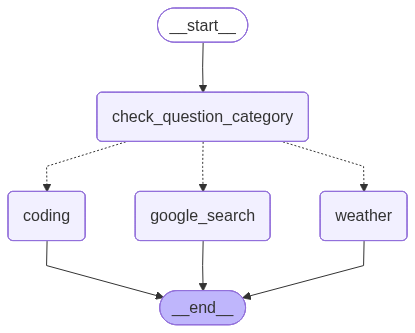

In [76]:
from IPython.display import Image 
Image(graph.get_graph().draw_mermaid_png())

In [79]:
response = graph.invoke({"question":"What is the address of Parliament House in New Delhi?"})

HTTPError: 403 Client Error: Forbidden for url: https://google.serper.dev/search?q=Parliament+House+New+Delhi+address&gl=us&hl=en&num=10

In [78]:
response

{'question': 'What is the address of geeks for geeks?',
 'category': 'google_search',
 'answer': ''}

#### GOOGLE AGENT TO GIVE THE ADDRESS -- ADDING A NODE TO GIVE ANSWERS FOR GOOGLE NODE 